# 1.2 Signal Variability Across CREs


### Should any peaks be filtered out due to insufficient signal?

Wie viel ATAC-Signal hat dieser Peak insgesamt über alle verwendeten Zelltypen/Samples?

In [ ]:
annotation_cols = [
    "ImmGenATAC1219.peakID",
    "Summit",
    "chrom",
    "mm10.60way.phastCons_scores",
    "_-log10_bestPvalue",
    "Included.in.systematic.analysis",
    "TSS",
    "genes.within.100Kb"
]

ATAC_signal = ATAC_pfiltered.drop(columns=annotation_cols)
peak_total = ATAC_signal.sum(axis=1)
peak_total.describe()

count    362330.000000
mean        458.318951
std         887.305913
min          24.420000
25%         137.700000
50%         207.290000
75%         407.510000
max       62693.390000
dtype: float64

Annotations-Spalten entfernen<br>
Gesamtsignal pro Peak berechnen (Peak 1: Signal in Sample1 + Sample2 ...; Peak 2: Signal in Sample1 + Sample2 ... )<br>

<h3>Low-Signal Peaks prüfen</h3>

In [ ]:
low_signal_peaks = peak_total == 0

print("Total CREs:", ATAC_signal.shape[0])
print("Zero-signal CREs:", low_signal_peaks.sum())
print("Percent zero-signal CREs:", low_signal_peaks.mean() * 100)

Total CREs: 362330
Zero-signal CREs: 0
Percent zero-signal CREs: 0.0


In [ ]:
nonzero_peak = (ATAC_signal > 0).sum(axis=1) # > Vergleichsoperator --> gibt boolean zurück
nonzero_peak.describe()

count    362330.0
mean         90.0
std           0.0
min          90.0
25%          90.0
50%          90.0
75%          90.0
max          90.0
dtype: float64

kein peak hat Gesamtsignal 0, jeder Peak hat in allen 90 Samples ein Signal > 0

In [ ]:
peak_total_signal = ATAC_signal.sum(axis=1)
peak_total_signal.describe()

count    362330.000000
mean        458.318951
std         887.305913
min          24.420000
25%         137.700000
50%         207.290000
75%         407.510000
max       62693.390000
dtype: float64

(array([1.0000e+00, 0.0000e+00, 2.0000e+00, 6.0000e+00, 8.0000e+00,
        2.0000e+01, 2.3000e+01, 5.7000e+01, 1.2800e+02, 2.1900e+02,
        4.3500e+02, 8.4000e+02, 1.4250e+03, 2.3650e+03, 3.6430e+03,
        5.6470e+03, 7.6470e+03, 1.0412e+04, 1.2624e+04, 1.4898e+04,
        1.7025e+04, 1.8141e+04, 1.8766e+04, 1.8252e+04, 1.7544e+04,
        1.6586e+04, 1.5476e+04, 1.4234e+04, 1.2741e+04, 1.1939e+04,
        1.0856e+04, 1.0098e+04, 9.2670e+03, 8.4030e+03, 7.9060e+03,
        7.4310e+03, 7.0310e+03, 6.3330e+03, 6.1450e+03, 5.6660e+03,
        5.2140e+03, 4.9440e+03, 4.5460e+03, 4.2320e+03, 3.9770e+03,
        3.6300e+03, 3.3000e+03, 3.0600e+03, 2.8740e+03, 2.5800e+03,
        2.3300e+03, 2.0980e+03, 1.8910e+03, 1.6970e+03, 1.5480e+03,
        1.3260e+03, 1.3010e+03, 1.1760e+03, 1.1100e+03, 1.0230e+03,
        9.4300e+02, 8.2500e+02, 7.3200e+02, 6.5600e+02, 6.1700e+02,
        5.8400e+02, 5.7000e+02, 5.2100e+02, 4.2900e+02, 3.8600e+02,
        3.3800e+02, 3.0800e+02, 2.7000e+02, 2.36

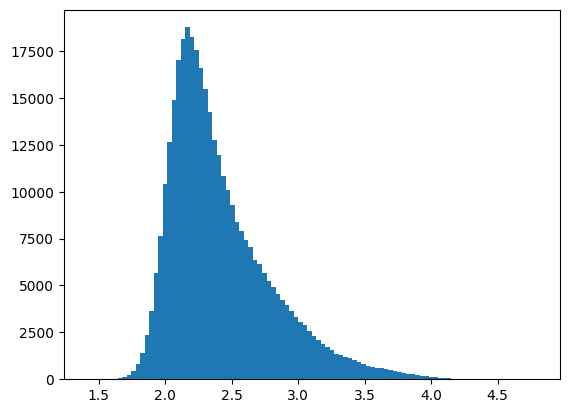

In [ ]:
plt.hist(np.log10(peak_total_signal + 1), bins=100)

<h3>Mittelwertfilter </h3>  </p> Mittelwertfilter anwenden amcht kein Sinn, weil haben schon geiltert macht kein zusätzlich Sinn noch anhand Mittelwert Werte zu entfernen
<br>Filter über niedrigen Mittelwert --> aber kann biologisch interessante sein, da sehr zelltypspezifische Peaks entfernt werden

### <p style="color: pink;"> Should any peaks be filtered out due to insufficient signal?: Summary</p>

The data come from a prefiltered and systematically analyzed OCR set. As described in the paper by Yoshida et al., the OCRs were sorted out, quantified, and normalized, thereby filtering out blacklisted genomic regions and chromosome homologous regions, thus removing possible artifacts. <br>
Also, when looking at the QC data (mmc1 data), the samples show sufficient quality, so no additional broad filtering of peaks due to insufficient signal was necessary. <br>
Additionaly all data with a p value under 0.05 (5%) were removed, setting a threshold for unreliable data and removing possible OCRs caused by background noise. <br>
Checking the minimum ATAC signal across the OCR, there were no peaks that had a signal of zero. There was no evidence for complet abscent signals and low signal peaks will be needed for analyzing the accesibility

# 2.4 CRE–Gene Association via Regression

## How much variance in gene expression can a regression model explain per gene

Regression: wie gut kann ich Genexpression durch ATAC Peaks vorhersagen?

### Theorie

Regressions Modelle

1. assuming a linear relationship <br>
<br>Y = Genexpression  <br>
X = Peak-Accessibility<br>
<br> **Intercept b0:** vorhersage der Expression von Gen, wenn die Accessibilty von Peak = 0 ist<br>
**Slope b1:** Wie stark sich die Expression ändert, wenn die Accessibility steigt<br>

$$\hat{Y}_i = b_0 + b_1 X_i$$

2. Parameters of the regression line are estimated using least-square method <br>
→ minimize the sum of squares of the deviations

$$\min_{b_0, b_1} \sum_{i=1}^{n} (Y_i - \hat{Y}_i)^2$$
$$b_0 = \bar{Y} - b_1 \cdot \bar{X}$$
$$b_1 = corr(X, Y) \frac{s_Y}{s_X}$$

<br> b1 berechnet sich aus Korrelationskoeffizient, Standardabweichungen von X und Y 


3. Residuen echter wert minus vorhergesagter Wert: $$e_i = Y_i - \hat{Y}_i$$

4. Vergleichen mit einem Nullmodell: Erklärt das Modell mehr als nur der Durschschnitt?

5. SST = SSM + SSR
* **$SST$ (Total Sum of Squares):** Gesamtvarianz in $Y$. Misst, wie stark die Genexpression insgesamt um ihren Mittelwert schwankt.
* **$SSM$ (Model Sum of Squares):** durch das Modell erklärte Varianz. Anteil der Varianz der Genexpression, welche direkt durch die Peak Accessibility erklärt werden kann (Abstand von der Regressionsgerade zum Mittelwert).
* **$SSR$ (Residual Sum of Squares):** nicht erklärte Varianz. Also die Summe der quadrierten Abweichungen zwischen den echten Messwerten und den Vorhersagen des Modells.
<br>
<br>

6. **R²** anteil der Gesamtvarianz welche durch das Modell erkärt wird --> **How much variance in gene expression can a regression model explain per gene?**
$$R^2=\frac{SSM}{SST}$$
* Modell funktionirt gut: Wenn möglichst viel der Varianz in SSM liegt und so wenig wie möglich in **SSR—> SSR < SSM**
​

<h3>Umsetzung Python</h3>

* ein Modell auf alle Zelltypen
* ein Modell spezifisch auf Tγδ

1. Gene wählen
* Tγδ-spezifische Gene (Tilmann: 2.2: hoher Gini) 
* vllt ein paar Houskeeping Gens als kontrolle?
2. ATAC Daten für alle Zelltypen oder auf Tγδ Zellen spezifisch (je nach Modell): Peaks pro Gen auswählen?
3. Matrix und dann Regression mit z.B. Funktion aus scikit 

### Funktion für R^2: all celltypes
(+ plot predict vs actual; + residuenplot)


<h3>Datensatz vorbereiten

In [122]:
import pandas as pd
from pathlib import Path

RNA_seq_path = Path('data') / 'mmc2.csv'
RNA_seq = pd.read_csv(RNA_seq_path)

ATAC_pfiltered_path = Path('data') / 'ATAC_pfiltered.csv'
ATAC_seq = pd.read_csv(ATAC_pfiltered_path)
ATAC_seq

,ImmGenATAC1219.peakID,chrom,Summit,mm10.60way.phastCons_scores,_-log10_bestPvalue,Included.in.systematic.analysis,TSS,genes.within.100Kb,LTHSC.34-.BM,LTHSC.34+.BM,...,DC.4+.Sp,DC.8+.Sp,DC.pDC.Sp,DC.103+11b+.SI,DC.103+11b-.SI,FRC.SLN,IAP.SLN,BEC.SLN,LEC.SLN,Ep.MEChi.Th
0,ImmGenATAC1219.peak_3,chr1,3120109,0.07,10.80,1.0,NaN,NaN,2.36,0.10,...,0.87,0.54,2.72,0.95,0.11,63.38,8.92,1.33,1.04,0.11
1,ImmGenATAC1219.peak_4,chr1,3121485,0.15,3.02,1.0,NaN,NaN,0.41,0.10,...,0.44,1.83,0.66,0.11,0.92,13.50,0.98,1.28,1.04,0.11
2,ImmGenATAC1219.peak_5,chr1,3372787,0.03,1.31,NaN,NaN,NaN,0.41,0.10,...,0.44,0.10,0.66,1.79,0.51,0.92,0.75,1.33,1.61,4.50
3,ImmGenATAC1219.peak_6,chr1,3399217,0.06,2.39,1.0,NaN,NaN,2.36,1.64,...,1.34,0.29,0.23,0.89,0.11,0.53,1.40,0.90,2.87,9.09
4,ImmGenATAC1219.peak_7,chr1,3400115,0.44,2.57,1.0,NaN,NaN,0.41,0.10,...,0.87,1.93,0.59,0.11,1.39,2.58,0.75,2.30,2.34,11.02
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
362325,ImmGenATAC1219.peak_512589,chrY,90811728,0.00,2.33,1.0,NaN,Erdr1,0.41,7.41,...,4.98,4.47,2.83,4.93,4.92,5.13,9.13,2.21,6.53,6.11
362326,ImmGenATAC1219.peak_512590,chrY,90812084,0.00,3.12,1.0,NaN,Erdr1,2.36,8.79,...,4.03,4.07,5.87,5.36,3.99,7.12,3.57,2.64,5.59,3.64
362327,ImmGenATAC1219.peak_512591,chrY,90812450,0.00,3.99,1.0,NaN,Erdr1,4.37,8.79,...,3.81,3.34,4.27,6.73,5.53,7.21,5.96,5.17,6.53,6.11
362328,ImmGenATAC1219.peak_512592,chrY,90812906,0.00,3.21,1.0,NaN,Erdr1,0.41,7.41,...,4.28,5.55,4.15,6.88,7.16,6.21,8.75,6.83,8.14,4.64


<h3> Funktion vom Regressionsmodell (R^2) für beliebige Gene 

Lineares Regressionsmodell war zu unzuverlässig aufgrund zu hoher Kollinearität der Peaks --> Lösung mit Ridge arbeiten
<br>
<br>Lineares Regressionsmodell: Parameters of the regression line are estimated using least-square method → minimize the sum of squares of the residuen <br> denn starke Korrelation --> große Koeffizienten <br>

deswegen **Ridge Modell** verwendet, welches penalty einführt für zu große Koeffizienten --> stabiler: 
<br> w: Koeffizient, y: Zielwerte ^2_2:Fehler für jeden einzelnen Datenpunkt quadriert und dann alle aufsummiert 
<br> $$\min_{w} ||Xw - y||^2_2 + \alpha ||w||^2_2$$
<br> least square: $$||Xw - y||^2_2$$ 
<br>penalty: alpha $$\alpha ||w||^2_2$$ 

Danach immernoch gleiches Problem: Kontrollieren mit **Cross validation**
<br> <br> skitlearn: 3.1. Cross-validation: evaluating estimator performance --> problem: overfitting (Modell passt sich zu perfekt an die Trainingsdaten ran) <br>

Lösung: Cross Validation:<br>
1. Die gesamten Daten werden in $K$ gleich große Teile (Folds/Blöcke) aufgeteilt (z. B. 5 Teile).<br>
2. Das Modell wird nun 5-mal hintereinander trainiert und getestet.<br>
3. In jedem Durchgang (Split) dient ein anderer Block als Testdaten (Validierungsdaten) und die restlichen 4 Blöcke als Trainingsdaten.<br>

Ergebnis: negative R^2 Werte: Modell zeigt IL17f-Expression schlechter als durch Mittelwert 
Grund: kaum Variation in den Daten --> alle Expresisonswerte bei 1 und haben auch nur 13 Zelltypen

Modell auf alle Zelldaten anwenden etwas besser

Matrix erstellen: X = peaks, Y = Gen-Expression

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge, RidgeCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
from sklearn.model_selection import cross_val_score, KFold
from sklearn.pipeline import make_pipeline


annotation_cols = ["ImmGenATAC1219.peakID", "chrom", "Summit",
                   "mm10.60way.phastCons_scores", "_-log10_bestPvalue",
                   "Included.in.systematic.analysis", "TSS", "genes.within.100Kb"]


def r2_gen(gen_name, plot=True, plot_residues=True):    # ohne top_k
    
    #Y: Gen-Expression
    RNA_seq_gen = RNA_seq[RNA_seq["Unnamed: 0"] == gen_name]  #Gen Namen von Unnamed in gen_name speichern
    y = RNA_seq_gen.drop("Unnamed: 0", axis=1, errors="ignore").T   #Unnamed zeile entfernen und Matrix transponiernen (Zelltypen sind Zeilen)

    # ATAC Datensatz Filtern, sodass nur peaks gewählt werden die mit Gen assoziert sind, also within 100kb
    ATAC_seq_gen = ATAC_seq[ATAC_seq["genes.within.100Kb"].fillna("").str.contains(rf"\b{gen_name}\b")]

    peak_ids = ATAC_seq_gen["ImmGenATAC1219.peakID"].values  # ← vor .T
    X = ATAC_seq_gen.drop(annotation_cols, axis=1, errors="ignore").T #ATAC datenstz transformieren: Spalten = Peaks


    #nur gemeinsame Zellen behalten behalten
    cells = X.index.intersection(y.index)
    X = X.loc[cells]
    y = y.loc[cells]

    X_scaled = StandardScaler().fit_transform(X) #Spaltenweise z-transformation

    # Ridge-Regressionamodell von scikit-learn
    # alpha ist penalty, wenn alpha = 0 keine Strafe #.fit: trainiert Modell

    ridge = RidgeCV(alphas=[10, 100, 1000, 10000, 100000],cv=KFold(5, shuffle=True, random_state=0))
    ridge.fit(X_scaled, y)

    #y wird verglichen mit vorhergesagten Wert und berechnet R^2 (wie viel Prozent der Expressionsvarianz das Modell erklärt)
    r2 = ridge.score(X_scaled, y)
    best_alpha = ridge.alpha_

    # Cross-Validation mit bestem alpha
    cv = cross_val_score(
        Ridge(alpha=best_alpha),
        X_scaled,y,
        cv=KFold(5, shuffle=True, random_state=0),
        scoring="r2").mean()
    
    y_true = np.ravel(y.values).flatten() #ravel: Ausgabe 1D --> verwenden für scatter plot
    y_pred = ridge.predict(X_scaled).flatten()

    if plot:
        plt.figure(figsize=(4, 6))
        Reg_vis = pd.DataFrame({"y_actual": y_true, "y_pred": y_pred}) #DataFrame mit y und yhut
        sns.scatterplot(data=Reg_vis, x="y_actual", y="y_pred", s=100, color="purple")      
        sns.regplot(data=Reg_vis, x="y_actual", y="y_pred", scatter=False, line_kws={"color": "thistle"})  
        plt.title(f"Actual vs Predicted R^2 for {gen_name}\nExpression across all cells")
        plt.savefig(f"plots_for_poster/Regressionplot of{gen_name}", dpi=300, bbox_inches="tight")
        plt.show()

    if plot_residues:
        residuals = y_true - y_pred
        Reg_vis = pd.DataFrame({"residuals": residuals, "y_pred": y_pred}) #DataFrame mit yhut und residuals
        sns.scatterplot(data=Reg_vis, x="y_pred", y="residuals", s=100)
        plt.axhline(0, color="red", linestyle="--")
        sns.regplot(data=Reg_vis, x="y_pred", y="residuals", ci=None,
                    scatter=False, line_kws={"color": "blue", "linestyle": "--"})
        plt.title(f"Residual plot {gen_name}-Expression across all cells")
        plt.show()
        

    return r2, cv, X.shape[1], ridge, best_alpha, peak_ids,y_pred, y_true

#### R²_gen for genes with highest Gini</h3> 
<br> Predicted Values und Residuenplot dargestellt

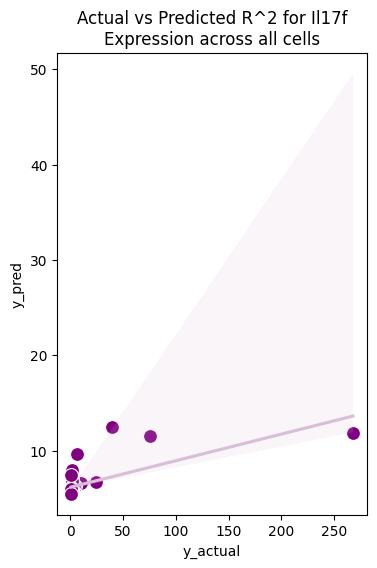

Il17f: R²=0.054, CV=-4.115, peaks=30, best_alpha=10000


In [172]:
for gen_name in ["Il17f"]: #, "Sox13", "Gzma", "Eomes", "Actb", "Rorc","Cd3d", "Rorc"
    r2, cv, n,_, best_alpha,_,_,_ = r2_gen(gen_name, plot_residues=False) #variabeln brauche ich hier für nicht
    print(f"{gen_name}: R²={r2:.3f}, CV={cv:.3f}, peaks={n}, best_alpha={best_alpha}") #Anzahl der peaks über Zellen hinweg

#### R²_gen for IL17 Genes</h3> 
<br> Predicted Values und Residuenplot dargestellt

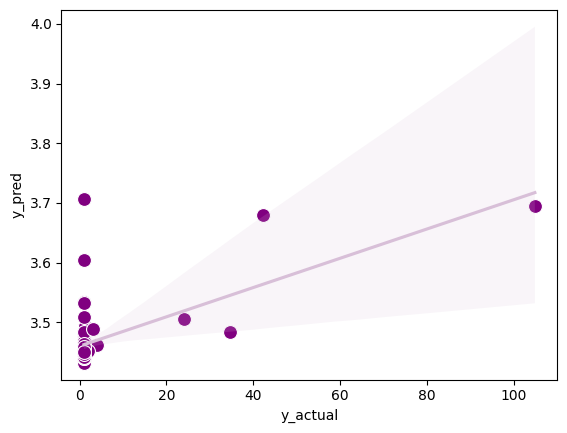

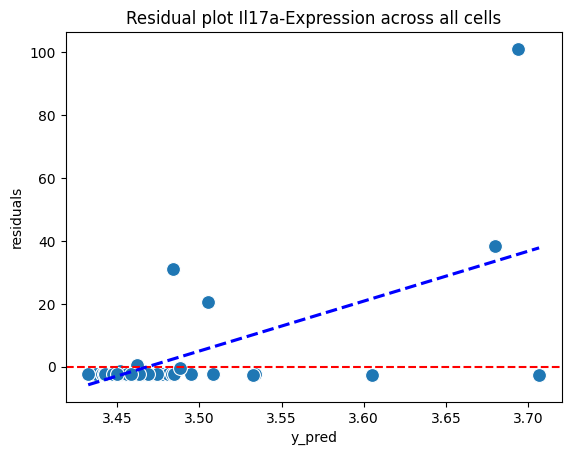

ValueError: too many values to unpack (expected 6)

In [125]:
for gen_name in ["Il17a", "Il17b", "Il17c", "Il17f"]: 
    r2, cv, n,_, best_alpha,_ = r2_gen(gen_name) #variabeln brauche ich hier für nicht
    print(f"{gen_name}: R²={r2:.3f}, CV={cv:.3f}, peaks={n}, best_alpha={best_alpha}") #Anzahl der peaks über Zellen hinweg

sehr großes alpha und teils noch negative CV Werte. Das Modell darf nicht quantiativ interpretiert werden. Im weiteren Verlauf eher dazu verwendet Regresssions Coeffizienten relativ zu vergleichen. 

R^2 hängt nur von sehr wenigen 2-3 hoch exprimierenden Zellen ab. Die meisten Punkte sind unten links (0,0), da IL17f bei sehr vielen Zellen kaum exprimiert wird.
<br> Rosa Bereich nach rechts zeigt sehr große Unischerheit.

### Funktion für R^2: Tγδ specific cells
(+ plot predict vs actual; + residuenplot)

<h3> Datensatz vorbereiten

In [ ]:
import pandas as pd
from pathlib import Path

RNA_seq_gd_path = Path('data') / 'RNA_seq_gd_anot.csv'
RNA_seq_gd = pd.read_csv(RNA_seq_gd_path)

ATAC_gd_path = Path('data') / 'ATAC_seq_gd.csv'
ATAC_seq_gd = pd.read_csv(ATAC_gd_path)

<h3> Funktion vom Regressionsmodell (R^2): Tγδ cells 

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns  
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge, RidgeCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
from sklearn.model_selection import cross_val_score, KFold
from sklearn.pipeline import make_pipeline 


annotation_cols = ["ImmGenATAC1219.peakID", "chrom", "Summit",
                   "mm10.60way.phastCons_scores", "_-log10_bestPvalue",
                   "Included.in.systematic.analysis", "TSS", "genes.within.100Kb"]


def r2_gen_gd(gen_name_gd, plot=True, plot_residues=True):   # top_k weg
    # RNA
    RNA_seq_Tgd_gen = RNA_seq_gd[RNA_seq_gd["Unnamed: 0"] == gen_name_gd]
    y = RNA_seq_Tgd_gen.drop("Unnamed: 0", axis=1, errors="ignore").T

    # ATAC Datensatz Filtern, sodass nur peaks gewählt werden die mit Gen assoziert sind, also within 100kb
    ATAC_seq_gen = ATAC_seq_gd[ATAC_seq_gd["genes.within.100Kb"].fillna("").str.contains(rf"\b{gen_name_gd}\b")]

    peak_ids = ATAC_seq_gen["ImmGenATAC1219.peakID"].values  # ← vor .T
    X = ATAC_seq_gen.drop(annotation_cols, axis=1, errors="ignore").T #ATAC datenstz transformieren: Spalten = Peaks

    # gemeinsame Zellen angleichen
    cells = X.index.intersection(y.index)
    X = X.loc[cells]
    y = y.loc[cells]
    
    X_scaled = StandardScaler().fit_transform(X)

    ridge = RidgeCV(alphas=[10, 100, 1000, 10000, 100000], cv=KFold(5, shuffle=True, random_state=0))
    ridge.fit(X_scaled, y)

    r2 = ridge.score(X_scaled, y)
    best_alpha = ridge.alpha_
    
    # CV mit bestem alpha
    cv = cross_val_score(
        Ridge(alpha=best_alpha),
        X_scaled, y,
        cv=KFold(5, shuffle=True, random_state=0),
        scoring="r2"
    ).mean()

    y_actual = np.ravel(y.values).flatten()
    y_pred = ridge.predict(X_scaled).flatten()

    if plot:
        Reg_vis = pd.DataFrame({"y_actual": y_actual, "y_pred": y_pred})
        sns.scatterplot(data=Reg_vis, x="y_actual", y="y_pred", s=100)
        sns.regplot(data=Reg_vis, x="y_actual", y="y_pred", scatter=False,
                    line_kws={"color": "red"})
        plt.title(f"Actual vs Predicted R^2 for {gen_name_gd}-Expression across Tgd cells")
        plt.show()

    if plot_residues:
        residuals = y_actual - y_pred
        Reg_vis = pd.DataFrame({"residuals": residuals, "y_pred": y_pred})
        sns.scatterplot(data=Reg_vis, x="y_pred", y="residuals", s=100)
        plt.axhline(0, color="red", linestyle="--")
        sns.regplot(data=Reg_vis, x="y_pred", y="residuals", ci=None,
                    scatter=False, line_kws={"color": "blue", "linestyle": "--"})
        plt.title(f"Residual plot {gen_name_gd}-Expression across Tgd cells")
        plt.show()
    
    return r2, cv, X.shape[1], ridge, best_alpha, peak_ids

<h3> R²_gen_gd for Genes mit hohem Gini-Koeffizient bei Tgd-Zellen</h3> 
<br> Predicted Values und Residuenplot dargestellt

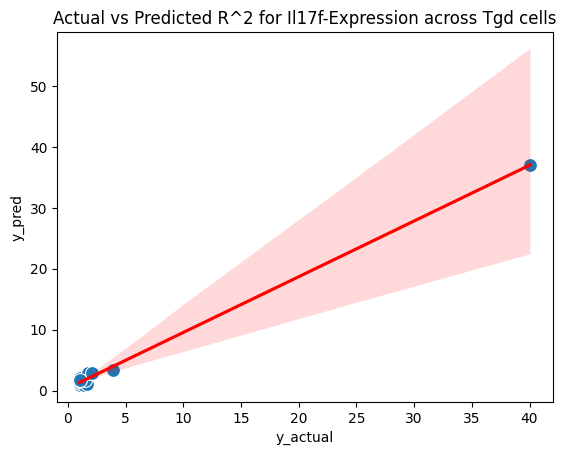

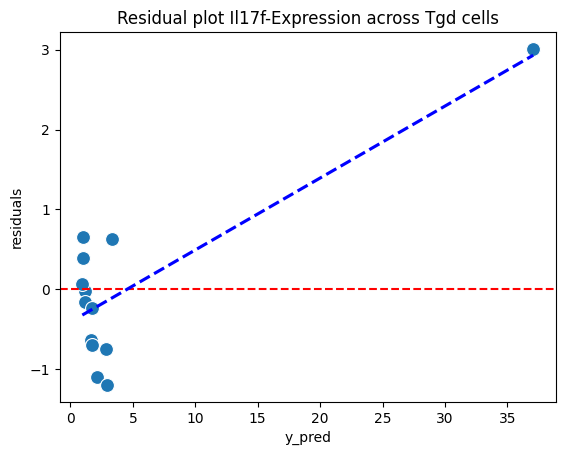

Il17f: R²=0.990, CV=-25.579, peaks=30, best_alpha=10


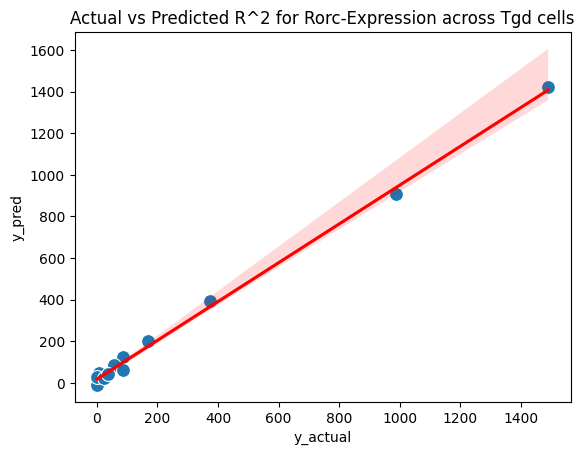

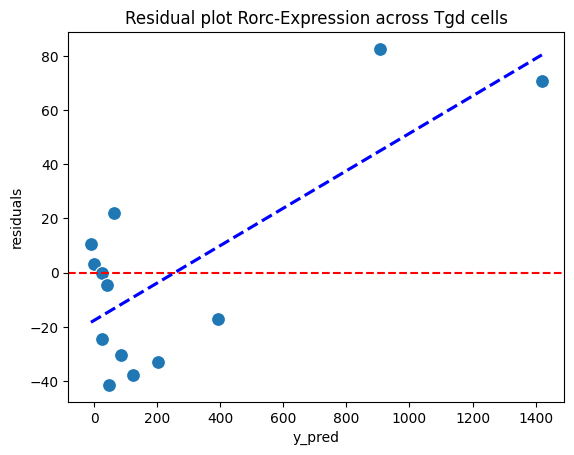

Rorc: R²=0.993, CV=-3908.351, peaks=55, best_alpha=10


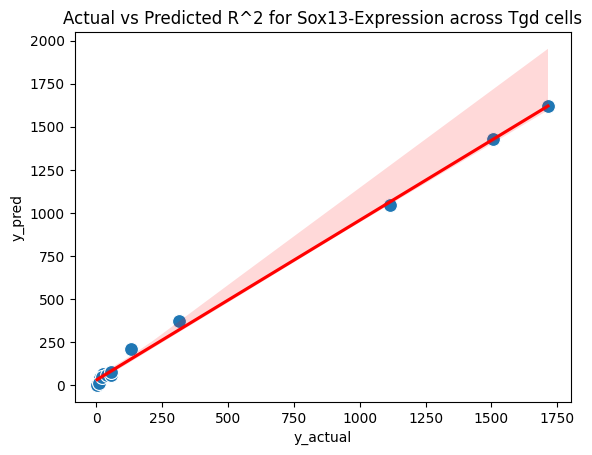

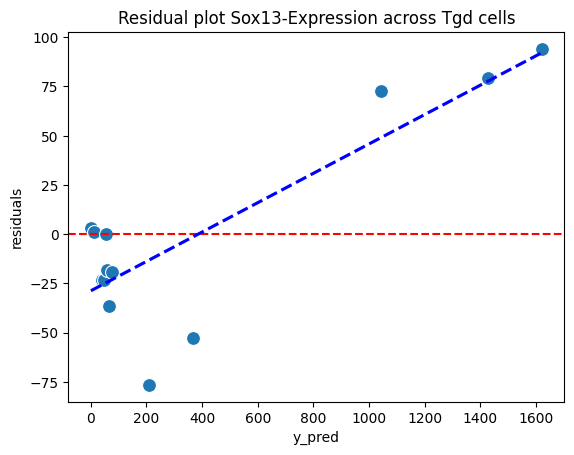

Sox13: R²=0.993, CV=-22.242, peaks=50, best_alpha=10


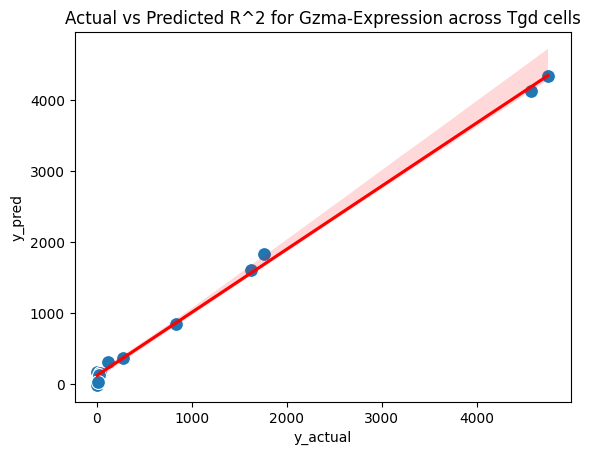

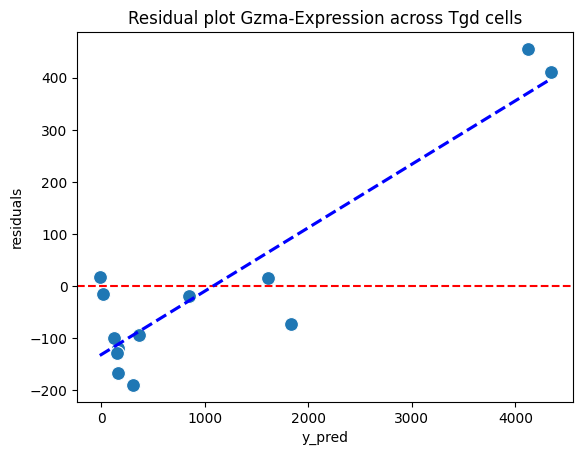

Gzma: R²=0.986, CV=-7.524, peaks=68, best_alpha=10


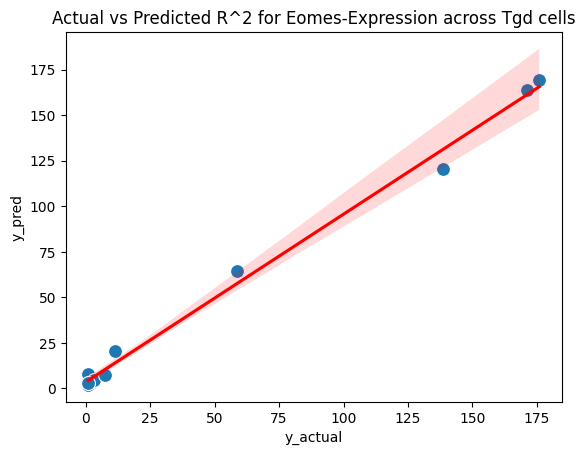

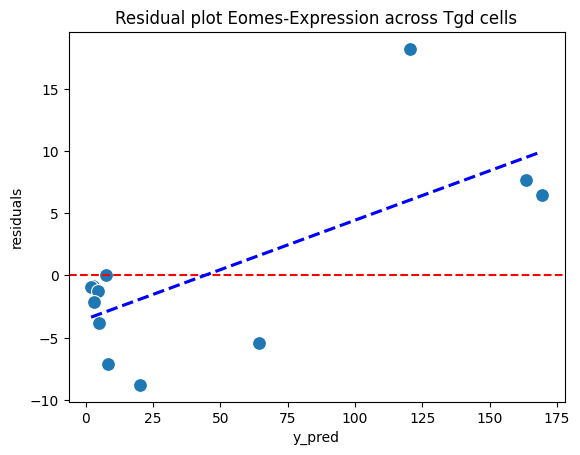

Eomes: R²=0.989, CV=-29856.268, peaks=62, best_alpha=10


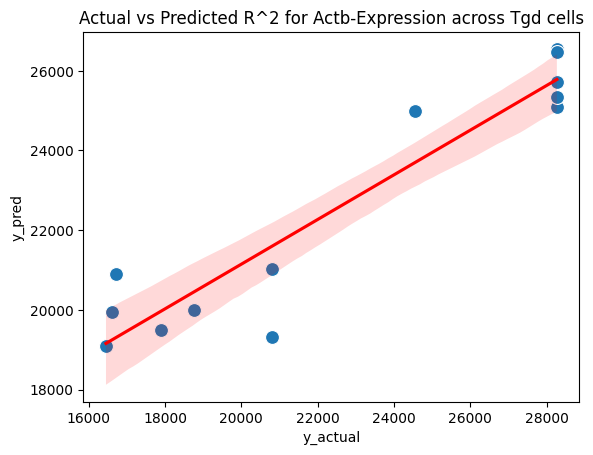

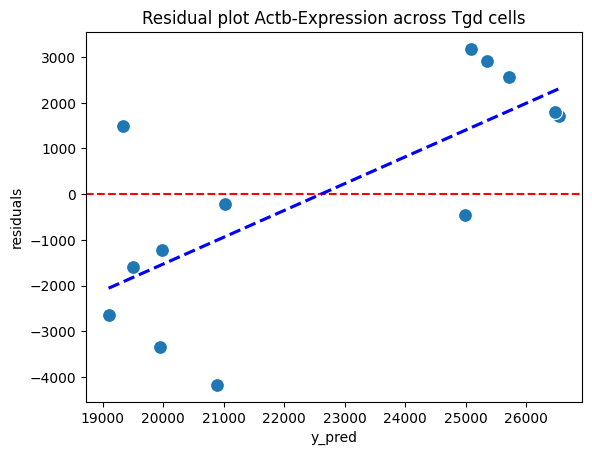

Actb: R²=0.768, CV=-0.889, peaks=85, best_alpha=100


In [ ]:
for gen_name_gd in ["Il17f", "Rorc", "Sox13", "Gzma", "Eomes", "Actb"]: 
    r2, cv, n,_,best_alpha, _ = r2_gen_gd(gen_name_gd)
    print(f"{gen_name_gd}: R²={r2:.3f}, CV={cv:.3f}, peaks={n}, best_alpha={best_alpha}") #Anzahl der peaks über Zellen hinweg

## How do regression coefficients change when the model is fit on your lineage alone versus all cell types?


b: Regressionskoeffizient
$$\hat{Y}_i = b_0 + b_1 X_i$$

b1,b2...bn: ein Koeffizient pro Peak

Ansatz: 
* für jedes Gen die gleichen Peaks (gemeinsamer Peak‑Satz für all‑cells und Tγδ).
* Für jeden Peak Vorzeichen der Koeffizienten vergleichen(all_cells vs. Tgd).
* Zählen, wie viele Peaks das Vorzeichen wechseln und wie groß der Anteil ist

<h3> Vergleich der Koeffizienten‑Werte bei verschiedenen Genen: Tabelle

In [131]:
genes = "Il17f", "Arpp21",  "Eomes", "Gzma", "Kcnk1", "Rorc", "Sox13", "Actb", "Hprt", "Rplp0" ,"Cd3d"
results = []
coef_tables = {}  # speichert coef_table pro Gen

for gen in genes:
    r2_all,cv_all, n_all,reg_all,best_alpha_all,peaks_all,_,_ = r2_gen(gen, plot=False, plot_residues = False) #increasing rigid penalty to reduce overfitting
    r2_gd, _, n_gd, reg_gd, best_alpha_gd, peaks_gd = r2_gen_gd(gen, plot=False, plot_residues=False)
    
    #nur gemeinsame Peaks (verhindert Längen-Mismatch)
    coef_table = pd.DataFrame(
        {"all_cells": reg_all.coef_.ravel(),
         "Tgd":       reg_gd.coef_.ravel()},
        index=peaks_all                           # ImmGenATAC1219.peakID als Index
    )

    coef_table["gene"] = gen  # Gen-Spalte hinzufügen
    coef_tables[gen] = coef_table  # speichern

    sign_changes = (np.sign(coef_table["all_cells"]) != np.sign(coef_table["Tgd"])).sum()
    
    results.append({                            #append: erweitert Liste
        "gene": gen,
        "n_peaks": len(coef_table),
        "sign_changes": sign_changes,
        "percent_sign_changes": 100 * sign_changes / len(coef_table)
        })



coef_genes_compare = pd.DataFrame(results)
coef_genes_compare

,gene,n_peaks,sign_changes,percent_sign_changes
0,Il17f,30,11,36.666667
1,Arpp21,56,15,26.785714
2,Eomes,62,25,40.322581
3,Gzma,68,32,47.058824
4,Kcnk1,33,6,18.181818
5,Rorc,55,18,32.727273
6,Sox13,50,10,20.000000
7,Actb,85,28,32.941176
8,Hprt,36,12,33.333333
9,Rplp0,78,27,34.615385


Houskeeping genes haben ähnliche Prozentwerte

#### Scatterplot
für ausgewählte Gene: Rorc, Gzma, Eomes, Actb_all
<br><br>

**Welche Peaks werden im Tgd Modell stärker oder schwächer gewichtet als im all cells Moell, und gibt es Vorzeichenwechsel?**

X-Achse: Regressionskoeffizient all cells<br>
Y-Achse: Regressionskoeffizient Tgd Modell.

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

def scattplot_coef(gen): 
    coef_table = coef_tables[gen].copy()
    
    coef_table["sign_changes"] = (np.sign(coef_table["all_cells"]) != np.sign(coef_table["Tgd"])).sum()
    coef_table["sign_changes"] = coef_table["sign_changes"].astype(bool)

    plt.figure(figsize=(6, 6))
    sns.scatterplot(
        data=coef_table,
        x="all_cells",
        y="Tgd",
        hue="sign_changes",
        palette={False: "steelblue", True: "tomato"},
        alpha=0.8
    )
    
    plt.axhline(0, color="grey", linestyle="--", linewidth=0.8)
    plt.axvline(0, color="grey", linestyle="--", linewidth=0.8)
    plt.plot(
        [coef_table["all_cells"].min(), coef_table["all_cells"].max()], #diagonale die perfekt 45 Grad Winkel verläuft
        [coef_table["all_cells"].min(), coef_table["all_cells"].max()],
        color="black", linestyle=":", linewidth=0.8,
        label="y = x"
    )

    plt.xlabel("Coefficient (all cells)")
    plt.ylabel("Coefficient (Tgd)")
    plt.title(f"{gen}: Regression coefficients\nall cells vs. Tgd")
    plt.legend(title="Sign change", loc="best")
    plt.tight_layout()
    plt.show()

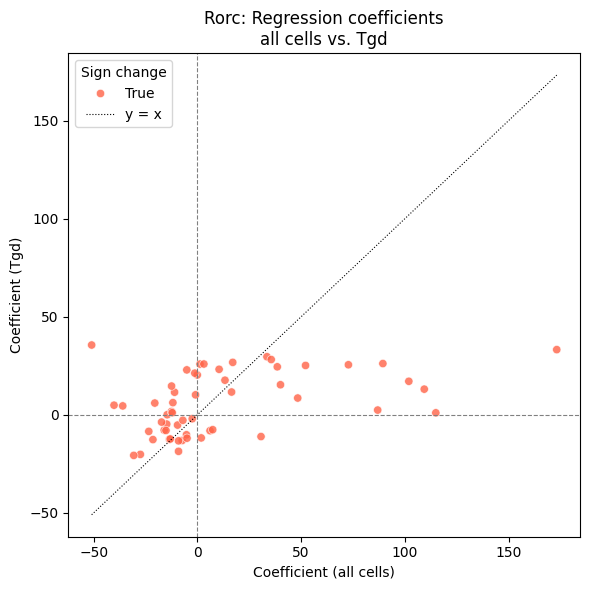

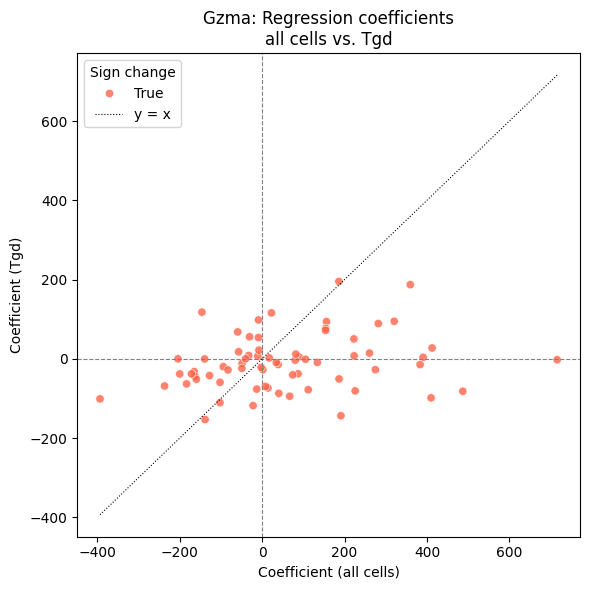

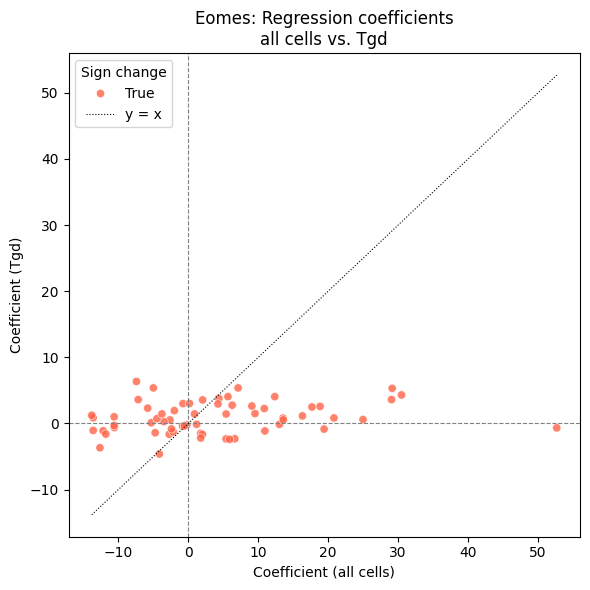

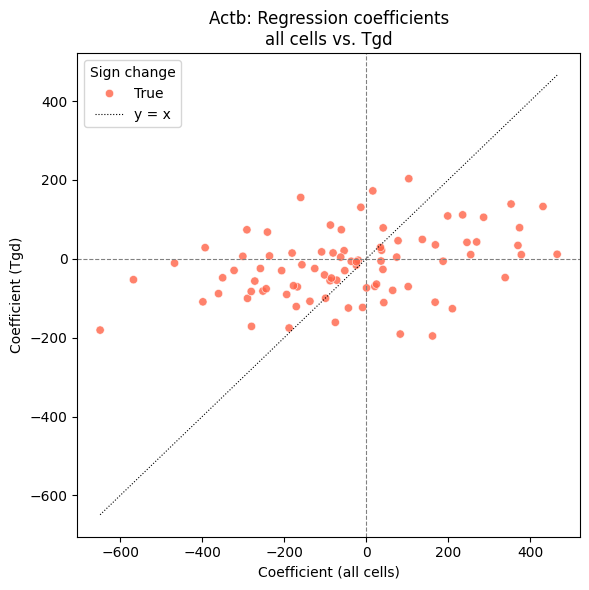

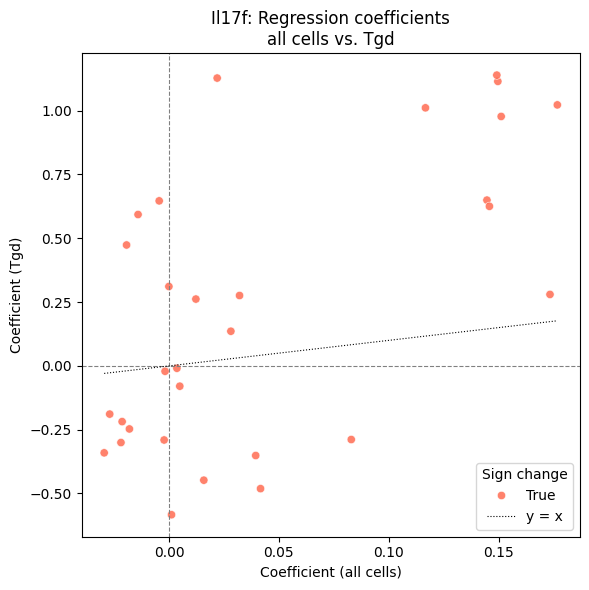

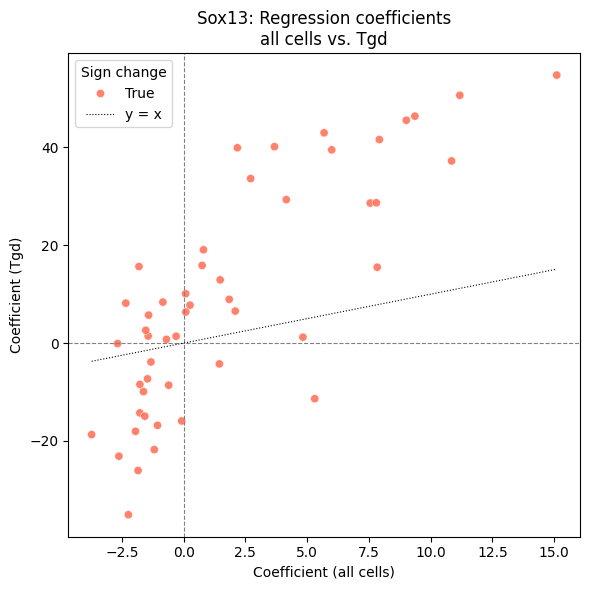

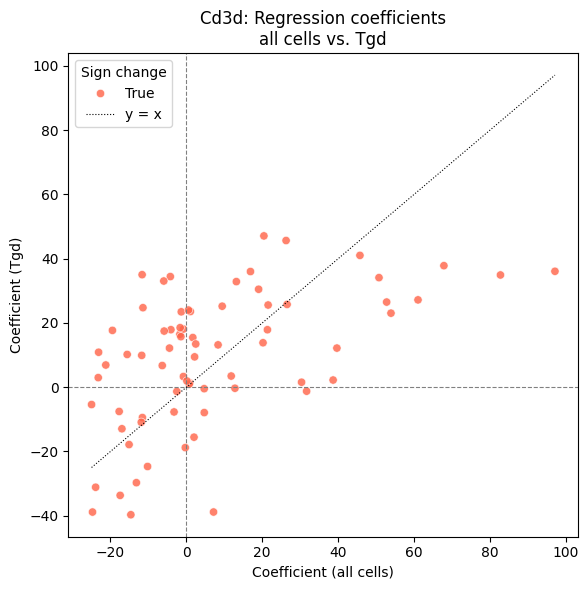

In [ ]:
for gen in ["Rorc", "Gzma", "Eomes", "Actb", "Il17f", "Sox13", "Cd3d"]:
    scattplot_coef(gen)

Actb (Houskeeping): Pukte sind relativ symmetrisch um diagonale verteilt --> Scatterplot ähnlcih wie bei den anderen

Il17f: Rigid Modell sieht kein klares Muster --> ist sehr tgd spezifisch, also in all cells fast unsichtbar --> bei tgd overfitting modell, versucht irgendwie sinnvollen koeffizient draus zumachen --> grenzen des Modells

Gzma, Eomes und Rorc ähnlch wie Actb verhält sind auch grenzen unseres modells und gleichzeitig sagt, das auch, dass Gzma,Eomes und Rorc über alle zellen hinaus eine gloabel stabile Beziehung.

## Which CREs drive expression of your lineage-specific genes?

In [132]:
high_gini_Tgd = ["Il17f", "Cd3d", "Rorc"]# "Gzma", "Kcnk1", "Rorc", "Sox13", "Il17f", "Cd3d"

for gen in high_gini_Tgd: 
    top_drive = coef_tables[gen][  
        #to-drive Filter: Tgd coefficient am unterschiedlichsten als all cells coefficient
        abs(coef_tables[gen]["Tgd"]) > abs(coef_tables[gen]["all_cells"])
    ].sort_values("Tgd", ascending=False) #sortiert mit größten Absatnd oben

    print(f"\n{gen} – Top Tγδ-driving CREs:")
    print(top_drive.head(10))


Il17f – Top Tγδ-driving CREs:
                          all_cells       Tgd   gene
ImmGenATAC1219.peak_2090   0.149211  1.139377  Il17f
ImmGenATAC1219.peak_2086   0.021907  1.127834  Il17f
ImmGenATAC1219.peak_2075   0.149677  1.114854  Il17f
ImmGenATAC1219.peak_2095   0.176759  1.022718  Il17f
ImmGenATAC1219.peak_2089   0.116722  1.011223  Il17f
ImmGenATAC1219.peak_2081   0.151196  0.977415  Il17f
ImmGenATAC1219.peak_2083   0.144711  0.649584  Il17f
ImmGenATAC1219.peak_2109  -0.004486  0.646648  Il17f
ImmGenATAC1219.peak_2085   0.145833  0.625246  Il17f
ImmGenATAC1219.peak_2116  -0.014109  0.593164  Il17f

Cd3d – Top Tγδ-driving CREs:
                            all_cells        Tgd  gene
ImmGenATAC1219.peak_482211  20.444442  47.107933  Cd3d
ImmGenATAC1219.peak_482197  26.288307  45.671452  Cd3d
ImmGenATAC1219.peak_482202  16.902648  36.017104  Cd3d
ImmGenATAC1219.peak_482214 -11.656547  35.037318  Cd3d
ImmGenATAC1219.peak_482179  -4.222625  34.445046  Cd3d
ImmGenATAC1219.peak_482201

**Visualization** <br>ridge regression to rank ATAC peaks within ±100 kb of each gene based on their contribution to predicting gene expression across cell types, and selected the top 5 Tγδ biased peaks per gene for visualization

/var/folders/cc/3r9cpp9s7c9_s16wz91nlkn40000gn/T/ipykernel_17044/566399959.py:122: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


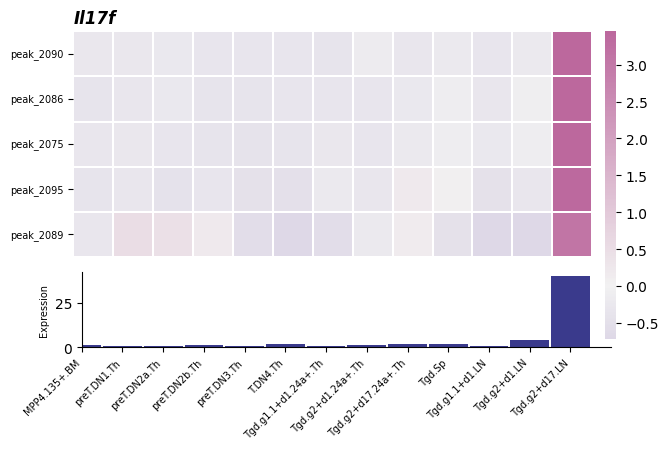

In [177]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

Tgd_cells = [
    "MPP4.135+.BM",
    "preT.DN1.Th",
    "preT.DN2a.Th",
    "preT.DN2b.Th",
    "preT.DN3.Th",
    "T.DN4.Th",
    "Tgd.g1.1+d1.24a+.Th",
    "Tgd.g2+d1.24a+.Th",
    "Tgd.g2+d17.24a+.Th",
    "Tgd.Sp",
    "Tgd.g1.1+d1.LN",
    "Tgd.g2+d1.LN",
    "Tgd.g2+d17.LN"
]

cmap = sns.diverging_palette(
    280,
    330,
    s=45,
    l=55,
    center="light",
    as_cmap=True
)

genes = ["Il17f"]#, "Il17f", "Cd3d", "Rorc"

fig = plt.figure(figsize=(7, 4 * len(genes)))
outer = fig.add_gridspec(
    len(genes), 2,
    width_ratios=[50, 1],
    wspace=0.05,
    hspace=0.7
)

for i, gen in enumerate(genes):
    # Inneres gridspec: Heatmap oben (3 Teile), Barplot unten (1 Teil)
    inner = outer[i, 0].subgridspec(2, 1, height_ratios=[3, 1], hspace=0.05)

    ax_heat = fig.add_subplot(inner[0])
    ax_bar = fig.add_subplot(inner[1], sharex=ax_heat)
    cax = fig.add_subplot(outer[i, 1])

    #Heatmap 
    #top 5 peaks von jedem gen nach Regressionsmodell: positiv Tgd peak und größten unterschied zu all cells
    top5 = coef_tables[gen][
        (coef_tables[gen]["Tgd"] > 0) &
        (coef_tables[gen]["Tgd"] > coef_tables[gen]["all_cells"])
    ].sort_values("Tgd", ascending=False).head(5)

    #jede zeile ist ein peak dieser top5 und davon die ATAC zugäglichkeit
    rows = []
    for peak_id in top5.index:
        row = ATAC_seq_gd[ATAC_seq_gd["ImmGenATAC1219.peakID"] == peak_id]
        if not row.empty:
            vals = row[Tgd_cells].iloc[0]
            sauberer_name = peak_id.replace("ImmGenATAC1219.", "")
            vals.name = sauberer_name

           
            rows.append(vals)

    heat_df = pd.DataFrame(rows)
    heat_df_z = StandardScaler().fit_transform(heat_df.T) # skaliert über Tgd-Zelltypen je Peak (dafür transformieren) --> damit alle peaks auf derselben skala liegen (z=2: Standartabweichung 2 besonders offen für den peak)
    heat_df_z = pd.DataFrame(heat_df_z.T, index=heat_df.index, columns=heat_df.columns)

    sns.heatmap(
        heat_df_z,
        ax=ax_heat,
        cmap=cmap,
        center=0,
        robust=True,
        linewidths=0.3,
        xticklabels=False,
        yticklabels=True,
        cbar=True,
        cbar_ax=cax
    )

    ax_heat.set_title(gen, fontstyle="italic", fontweight="bold", loc="left")

    # Heatmap-Zellnamen kleiner
    ax_heat.tick_params(axis='x', labelbottom=False, bottom=False)   # z.B. 7 oder 8
    ax_heat.tick_params(axis='y', labelsize=7)   # z.B. 7 oder 8

    rna_row = RNA_seq_gd[RNA_seq_gd["Unnamed: 0"] == gen]
    # Barplot RNA: RNA‑Expression des Gens in den Tγδ‑Zelltypen
    if not rna_row.empty:
        rna_vals = rna_row[Tgd_cells].iloc[0]

        ax_bar.bar(
            np.arange(len(Tgd_cells)),
            rna_vals.values,
            width=0.95,
            color="#3a3a8c"
        )
        ax_bar.set_xticks(np.arange(len(Tgd_cells)))
        ax_bar.set_xticklabels(Tgd_cells, rotation=45, ha="right", fontsize=7)
        ax_bar.set_ylabel("Expression", fontsize=7)
        ax_bar.spines[["top", "right"]].set_visible(False)

    ax_heat.set_xlim(0, len(Tgd_cells))
    ax_bar.set_xlim(0, len(Tgd_cells))

    heat_pos = ax_heat.get_position()
    bar_pos = ax_bar.get_position()

    # Barplot nach rechts, nach unten und etwas länger
    ax_bar.set_position([
        heat_pos.x0 + 0.012,      # nach rechts
        bar_pos.y0 - 0.02,        # nach unten
        heat_pos.width + 0.015,   # etwas länger/breiter
        bar_pos.height
    ])
plt.savefig(f"plots_for_poster/top_peaks_ATAC_RNA_{genes}", dpi=300, bbox_inches="tight")
plt.tight_layout()
plt.show()

für jedes Gen die Top‑5 Peaks nach Tγδ‑Koeffizienten bestimmt (die stärksten positiven Regressionskoeffizienten aufweisen und deren Einfluss dort größer ist als im all cells Modell)

* oben: ATAC‑Zugänglichkeit dieser Peaks über alle Zelltypen (Heatmap),

* unten: RNA‑Expression des Gens in denselben Zelltypen (Balken).

<br> Beobachtung

* In welchen Tγδ‑Subtypen sind diese „modell‑wichtigen“ CREs am stärksten offen
* Ob das Gen dort am stärksten exprimiert ist

Es wird sichtbar, in welchen Tγδ stadien hohe enhancer Aktivität und hohe Genexpression zusammenfallen, also wo die durch das Regressionsmodell identifizierten CREs die lineage spezifische Expression am stärksten zu treiben scheinen.

Peaks durch Modell gewählt --> ABER nicht dazu, dass sie quantitativ etwas bestimmen, also das ein bestimmter Peak einen bestimmten % Anteil der Varianz erklärt, das funktioniert nciht, weil es zu unzuverlässig ist

**Interpretation**
* Eomes: spät/Tγδ spezifische CREs, vllt für Reifung in bestimmten Geweben relevant
* Gzma: breitere Expression über mehrere Tgd‑Subtypen und erhöhte Zugänglichkeit in mehreren dieser Tgd‑Subsets
* Kck1: LN‑spezifisch in Tγδ‑Zellen aktiviert zu sein
* Rorc und Sox13: spät aber auch vor allem Il17f spez.


WICHTIG ZU SCHAUEN ON DAS ENHANCERS SIND UND DANNA AGUMENTIEREN FOLGEN ENAHNCER UND NICHT PROMOTOR DRIVEN LOGIC: plot sieht gleich wenn man davor TSS raus macht oder auch nicht

In [ ]:
plt.savefig('plots for poster/Regression', dpi=300)
